# Option analytics: five ways to say the cross-section moves together

Every model up to here predicted a stock's return from that stock's own features. The
latent-factor family starts somewhere else: suppose most of what happens to any one stock in a
week is a few common movements it is exposed to. Then the objects worth estimating are those
movements and each stock's exposure to them, and a forecast is what the exposures imply.

**That idea admits several estimators, and this case study fits five.** They are published one per
notebook rather than together, because they differ in what they are allowed to see and in what
they are fitted to do, and a table that mixed them would hide exactly the distinctions worth
reading:

| Notebook | Model | Exposures come from | Fitted to |
| --- | --- | --- | --- |
| [`11a_pca`](11a_pca.ipynb) | `pca` | the return panel alone | describe the panel |
| [`11b_ipca`](11b_ipca.ipynb) | `ipca` | a linear map of the characteristics | describe the panel |
| [`11c_conditional_autoencoder`](11c_conditional_autoencoder.ipynb) | `cae` | a network on the characteristics | describe the panel |
| [`11d_stochastic_discount_factor`](11d_stochastic_discount_factor.ipynb) | `sdf` | no exposures - a pricing kernel | price the cross-section |
| [`11e_supervised_autoencoder`](11e_supervised_autoencoder.ipynb) | `sae` | a network on the characteristics | describe the panel *and* predict |

**Read down the third column and then across the fourth.** The first three rows differ only in the
functional form of one map, which makes them a clean sequence: unconditioned, linear, nonlinear.
The fourth is a different question rather than a different form. The fifth is the third with the
forward return added to the loss, which makes `11c` and `11e` the one controlled pair in the
family.

**This notebook does not rank them.** It reads the five populations the sibling notebooks
published, checks that between them they cover every model the training menus declare, and puts
their validation IC side by side so the family can be seen at once. Selection happens in
[`14_backtest`](14_backtest.ipynb), on validation backtest Sharpe, over every checkpoint of every
model - not on the IC shown here.

**Learning objectives.** By the end of this notebook you will be able to:

- Say what the five estimators have in common and along which two axes they differ.
- Check that a family split across notebooks covers its declared menu, and detect it when it
  does not.
- Read a family-level IC comparison without treating it as a selection.

**Book reference**: Chapter 14 (latent factor models), Sections 14.2 through 14.6.

**Prerequisites**: the five sibling notebooks have run and published their populations. This one
reads the registry and fits nothing.

**What it writes**: nothing. It is a read-only view over what the five siblings registered.

In [1]:
"""Read the five published latent-factor populations as one family view."""

import re

import plotly.graph_objects as go
import polars as pl

from case_studies.research import PredictionCatalog, configured_model_menu, open_study
from utils.paths import REPO_ROOT
from utils.style import COLORS, show_plotly_with_alt

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

In [3]:
study = open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Does the family's split cover its menu?

A family fitted in one notebook cannot silently lose a model: the notebook loads the menu and
fits what it finds. A family split across five notebooks can, because each notebook names the one
model it publishes and nothing checks the union. A model added to the training menus with no
notebook to publish it would simply never be fitted, and the only symptom downstream would be a
family that looks smaller than it is.

So the union is checked here. Each sibling declares `MODEL_NAME` in its parameters cell; the
notebooks are read as **source files** from the repository, not from the case study's data
directory, because `ML4T_OUTPUT_DIR` redirects the latter and the glob would then find nothing.
An empty glob raises rather than reporting every declared model as unclaimed - those are different
failures and would otherwise look identical.

In [4]:
notebook_dir = REPO_ROOT / "case_studies" / CASE_STUDY_ID
siblings = sorted(notebook_dir.glob("11[a-z]_*.py"))
if not siblings:
    raise RuntimeError(f"no latent-factor sibling notebooks found under {notebook_dir}")

claimed: dict[str, str] = {}
for path in siblings:
    match = re.search(r'^MODEL_NAME\s*=\s*"([^"]+)"', path.read_text(), re.MULTILINE)
    if match is None:
        raise RuntimeError(f"{path.name} declares no MODEL_NAME in its parameters cell")
    claimed[match.group(1)] = path.name

menu = configured_model_menu(CASE_STUDY_ID).filter(pl.col("family") == "latent_factors")
declared_models = set(menu.get_column("config_name"))
if declared_models != set(claimed):
    raise RuntimeError(
        f"the training menus declare {sorted(declared_models)} but the notebooks publish "
        f"{sorted(claimed)}; unclaimed {sorted(declared_models - set(claimed))}, "
        f"unmenued {sorted(set(claimed) - declared_models)}"
    )
pl.DataFrame(
    {"config_name": sorted(claimed), "published_by": [claimed[name] for name in sorted(claimed)]}
)

config_name,published_by
str,str
"""cae""","""11c_conditional_autoencoder.py"""
"""ipca""","""11b_ipca.py"""
"""pca""","""11a_pca.py"""
"""sae""","""11e_supervised_autoencoder.py"""
"""sdf""","""11d_stochastic_discount_factor…"


## 2. What the five populations hold

`PredictionCatalog` is the registry read the whole case study shares, so this table is the same
rows [`13_model_analysis`](13_model_analysis.ipynb) reads rather than a second derivation of them.

`checkpoints` is where the family's members stop looking alike. PCA and IPCA are solved: one fold
produces one answer, so they publish a single checkpoint. The two autoencoders are trained on a
declared epoch schedule. The stochastic discount factor publishes its scheduled epochs and, in
addition, the states its library captured by reading the validation split - which is why its count
is the odd one and why [`11d`](11d_stochastic_discount_factor.ipynb) separates the two kinds.

In [5]:
catalog = (
    PredictionCatalog(study)
    .table(include_preview=EXECUTION_TIER == "preview")
    .filter((pl.col("family") == "latent_factors") & (pl.col("split") == "validation"))
)
if catalog.is_empty():
    raise RuntimeError(
        "no latent-factor validation rows are registered; run the five sibling notebooks first"
    )

coverage = (
    catalog.group_by("config_name")
    .agg(
        labels=pl.col("label").n_unique(),
        checkpoints=pl.col("checkpoint_value").n_unique(),
        prediction_sets=pl.len(),
        all_complete=pl.col("complete").all(),
        scored_dates=pl.col("ic_n_days").max(),
    )
    .sort("config_name")
)
if not coverage.get_column("all_complete").all():
    raise RuntimeError("a partial latent-factor prediction set cannot pass to backtesting")
coverage

config_name,labels,checkpoints,prediction_sets,all_complete,scored_dates
str,u32,u32,u32,bool,f64
"""cae""",3,10,60,true,497.0
"""ipca""",3,1,6,true,497.0
"""pca""",3,1,6,true,497.0
"""sae""",3,10,40,true,497.0
"""sdf""",3,5,30,true,497.0


## 3. The family side by side

One point per model and label: the highest validation IC that model reached on that label, across
every checkpoint it published. **That is a selection, and it is made here only to draw the
picture.** A model with ten checkpoints has ten chances to reach a high point and a model with one
has one, so the models are not on equal terms in this figure and the vertical spread within a
column says more than the ordering across columns does.

What the figure is for is the shape: whether conditioning the exposures on the option surface
moves the family at all, and whether any of it clears zero on any target. Both are answerable by
looking; neither is answered by ranking.

In [6]:
peaks = (
    catalog.group_by("config_name", "label")
    .agg(
        peak_ic=pl.col("ic_mean").max(),
        checkpoints=pl.col("checkpoint_value").n_unique(),
    )
    .sort("config_name", "label")
)
peaks

config_name,label,peak_ic,checkpoints
str,str,f64,u32
"""cae""","""fwd_ret_10d""",0.002935,10
"""cae""","""fwd_ret_5d""",0.002398,10
"""cae""","""fwd_ret_risk_adj_5d""",0.007709,10
"""ipca""","""fwd_ret_10d""",-0.008197,1
"""ipca""","""fwd_ret_5d""",0.001611,1
…,…,…,…
"""sae""","""fwd_ret_5d""",0.009646,10
"""sae""","""fwd_ret_risk_adj_5d""",0.028432,10
"""sdf""","""fwd_ret_10d""",0.010129,5


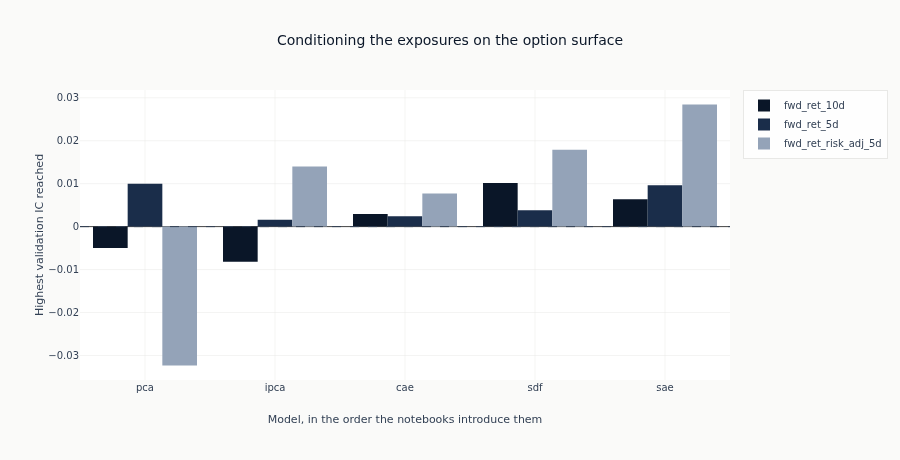

In [7]:
model_order = ["pca", "ipca", "cae", "sdf", "sae"]
present_models = [name for name in model_order if name in set(peaks.get_column("config_name"))]
present_models += sorted(set(peaks.get_column("config_name")) - set(present_models))
labels_present = sorted(set(peaks.get_column("label")))

fig = go.Figure()
for index, label in enumerate(labels_present):
    rows = peaks.filter(pl.col("label") == label)
    ordered = pl.DataFrame({"config_name": present_models}).join(rows, on="config_name", how="left")
    fig.add_trace(
        go.Bar(
            x=ordered.get_column("config_name").to_list(),
            y=ordered.get_column("peak_ic").to_list(),
            name=label,
            marker_color=[COLORS["blue"], COLORS["slate"], COLORS["recede"]][index % 3],
        )
    )
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_yaxes(title_text="Highest validation IC reached")
fig.update_xaxes(title_text="Model, in the order the notebooks introduce them")
fig.update_layout(
    barmode="group",
    title="Conditioning the exposures on the option surface",
    height=460,
    width=900,
    margin=dict(t=90),
)
# Which side of zero each bar sits on is a fact about the frame, so the alt text counts it rather
# than asserting a shape the next run may not reproduce.
above = (
    peaks.filter(pl.col("peak_ic") > 0).group_by("config_name").agg(n=pl.len()).sort("config_name")
)
counted = "; ".join(
    f"{row['config_name']} above zero on {row['n']}" for row in above.iter_rows(named=True)
)
show_plotly_with_alt(
    fig,
    "Grouped bar chart of the highest validation information coefficient each model reached, one "
    "group of bars per model in the order the notebooks introduce them and one bar per label "
    f"within each group, with a dashed zero line. Counted from the frame, of the {len(labels_present)} "
    f"labels: {counted or 'no model is above zero on any label'}.",
)

## 4. What to notice

**The three describe-the-panel models are a sequence, so read them as one.** PCA cannot see the
option surface at all, IPCA maps it to the exposures linearly, and the conditional autoencoder
maps it through a network. Whatever conditioning is worth on this cross-section is the distance
between the first bar and the next two, and whatever nonlinearity is worth on top of that is the
distance between the second and the third. Neither distance is assumed anywhere; both are in the
figure.

**The two remaining models each break the sequence in a different direction.** The stochastic
discount factor changes the question from *how does this move together* to *what prices this*, so
its bar is not a further step along the same axis. The supervised autoencoder keeps the
conditional autoencoder's architecture and adds the forward return to the loss, which makes those
two the only pair in the family that differs by a single term.

**A high bar here is not a signal, and a bar count is not a ranking.** The IC measures whether
predictions order the cross-section, on two folds, with overlapping multi-day returns making
successive days dependent. Each sibling notebook reports a HAC statistic beside its own numbers
and each says the same thing about it: it is a diagnostic, not a test. What decides which model
reaches a strategy is [`14_backtest`](14_backtest.ipynb), on validation backtest Sharpe, after
costs and turnover.

**Known limitations.** Every caveat in the sibling notebooks applies here and is not repeated:
two folds, one of them validating on 2020; declared rather than searched factor counts; no
adjustment for serial dependence in the IC. Two further ones are specific to this view.
The peak-across-checkpoints reduction favours the models that publish more checkpoints, as noted
above. And the five models were fitted by five separate notebooks, so nothing guarantees they saw
the same code revision - the populations carry their own training identities, which is what makes
that checkable rather than assumed.

**Next**: [`12_causal_dml`](12_causal_dml.ipynb) leaves prediction behind for a different
question - what a change in one feature does to the return, rather than what the features jointly
predict. [`13_model_analysis`](13_model_analysis.ipynb) puts this family beside the supervised
ones.